# Vehicle Insurance Prediction

## Objective

The objective of this project is to build a machine learning model that predicts whether a customer will be interested in purchasing vehicle insurance based on demographic and vehicle-related information.

The workflow includes:

- Data preprocessing
- Feature engineering
- Handling class imbalance
- Model comparison
- Hyperparameter tuning
- Final model selection and evaluation

## Import Packages and CSV

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Preprocessing

In [2]:
df = pd.read_csv("data.csv")

In [3]:
df.isnull().sum()

id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

There is no null or duplicated values

In [5]:
df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [6]:
df = df.drop("id", axis =1)

In [7]:
df.head()

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


## Preprocessing Pipeline

In [8]:
df.nunique()

Gender                      2
Age                        66
Driving_License             2
Region_Code                53
Previously_Insured          2
Vehicle_Age                 3
Vehicle_Damage              2
Annual_Premium          48838
Policy_Sales_Channel      155
Vintage                   290
Response                    2
dtype: int64

In [9]:
numeric_features = ["Age", "Annual_Premium", "Vintage"]
binary_features = ["Driving_License", "Previously_Insured" ]
ordinal_features = ["Gender", "Vehicle_Age", "Vehicle_Damage"]
nominal_features = ["Region_Code", "Policy_Sales_Channel"]

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler,
    OrdinalEncoder,
    OneHotEncoder
)
from sklearn.impute import SimpleImputer


numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


binary_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(categories=[
        ["Female", "Male"],
        ["< 1 Year", "1-2 Year", "> 2 Years"],
        ["No", "Yes"]
    ]))  
])

nominal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output= False))   
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("bin", binary_pipeline, binary_features),
    ("ord", ordinal_pipeline, ordinal_features),
    ("nom", nominal_pipeline, nominal_features)
])

## Train Test Split

In [11]:
X = df.drop("Response", axis = 1)
y = df["Response"]

In [12]:
y.head()

0    1
1    0
2    1
3    0
4    0
Name: Response, dtype: int64

## Handling Class Imbalance

The target variable is highly imbalanced (~88% negative and ~12% positive).

Instead of aggressive resampling techniques, class-weight based learning was adopted to reduce bias toward the majority class while preserving the original data distribution.

## Note

SMOTEENN was initially evaluated to address class imbalance. However, it introduced a noticeable performance drop on the unseen test data. Therefore, the final model was trained using class-weight based imbalance handling instead.

Checking imbalance

In [13]:
print(y.value_counts())

print(y.value_counts(normalize=True))

Response
0    334399
1     46710
Name: count, dtype: int64
Response
0    0.877437
1    0.122563
Name: proportion, dtype: float64


In [14]:
negative = y.value_counts()[0]
positive = y.value_counts()[1]
scale_pos_weight = round(negative / positive, 2)
scale_pos_weight # scale_pos_weight for XGBClassifier algorithn

np.float64(7.16)

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size= 0.2, random_state=42, stratify=y)

In [16]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

### Importing Models

In [17]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, roc_auc_score

In [18]:
def evaluate_clf(true, predicted):
    acc = accuracy_score(true, predicted)
    f1 = f1_score(true, predicted)
    precision = precision_score(true, predicted)
    recall  = recall_score(true, predicted)

    return acc, f1, precision, recall

In [19]:
models = {
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "K-Neighbors Classifier": KNeighborsClassifier(),
    "XGBClassifier": XGBClassifier(scale_pos_weight = scale_pos_weight, random_state=42), 
    "CatBoosting Classifier": CatBoostClassifier(auto_class_weights='Balanced', verbose=False, random_state=42),
    "AdaBoost Classifier": AdaBoostClassifier(random_state=42)
}

In [20]:
def evaluate_models(X_train, X_test, y_train, y_test, models):

    models_list = []
    accuracy_list = []
    auc = []

    for i in range(len(list(models))):
        model = list(models.values())[i]
        model.fit(X_train, y_train)

        # Make predictions
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        y_train_prob =  model.predict_proba(X_train)[:, 1]
        y_test_prob = model.predict_proba(X_test)[:, 1]


        # Training set performance
        model_train_accuracy, model_train_f1, model_train_precision, model_train_recall= evaluate_clf(y_train, y_train_pred)
        model_train_rocauc_score = roc_auc_score(y_train, y_train_prob)

        # Training set performance
        model_test_accuracy, model_test_f1, model_test_precision, model_test_recall = evaluate_clf(y_test, y_test_pred)
        model_test_rocauc_score = roc_auc_score(y_test, y_test_prob)

        print(list(models.keys())[i])
        models_list.append(list(models.keys())[i])


        print('Model performance for Training set')
        print("- Accuracy: {:.4f}".format(model_train_accuracy))
        print('- F1 score: {:.4f}'.format(model_train_f1)) 
        print('- Precision: {:.4f}'.format(model_train_precision))
        print('- Recall: {:.4f}'.format(model_train_recall))
        print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))

        print('----------------------------------')

        print('Model performance for Test set')
        print('- Accuracy: {:.4f}'.format(model_test_accuracy))
        accuracy_list.append(model_test_accuracy)
        print('- F1 score: {:.4f}'.format(model_test_f1))
        print('- Precision: {:.4f}'.format(model_test_precision))
        print('- Recall: {:.4f}'.format(model_test_recall))
        print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))
        auc.append(model_test_rocauc_score)
        print('='*35)
        print('\n')

    report=pd.DataFrame(list(zip(models_list, accuracy_list)), columns=['Model Name', 'Accuracy']).sort_values(by=['Accuracy'], ascending=False)

    return report

In [21]:
base_model_report = evaluate_models(
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    models=models
)

Random Forest
Model performance for Training set
- Accuracy: 0.9998
- F1 score: 0.9994
- Precision: 0.9991
- Recall: 0.9997
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.8653
- F1 score: 0.1904
- Precision: 0.3615
- Recall: 0.1292
- Roc Auc Score: 0.8308


Decision Tree
Model performance for Training set
- Accuracy: 0.9999
- F1 score: 0.9995
- Precision: 0.9991
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.8247
- F1 score: 0.3006
- Precision: 0.2941
- Recall: 0.3074
- Roc Auc Score: 0.6022


Gradient Boosting
Model performance for Training set
- Accuracy: 0.8775
- F1 score: 0.0004
- Precision: 1.0000
- Recall: 0.0002
- Roc Auc Score: 0.8573
----------------------------------
Model performance for Test set
- Accuracy: 0.8774
- F1 score: 0.0000
- Precision: 0.0000
- Recall: 0.0000
- Roc Auc Score: 0.8561


Logistic Regression
Model performance for Training 

c:\Users\masud\.conda\envs\vehicle\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\masud\.conda\envs\vehicle\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [22]:
base_model_report

,Model Name,Accuracy
7,AdaBoost Classifier,0.877437
2,Gradient Boosting,0.877398
0,Random Forest,0.865301
4,K-Neighbors Classifier,0.855002
1,Decision Tree,0.824657
6,CatBoosting Classifier,0.718572
5,XGBClassifier,0.713101
3,Logistic Regression,0.695416


## Model Selection

After evaluating multiple machine learning algorithms, the following three models were selected for hyperparameter tuning:

- XGBoost
- CatBoost
- Random Forest

These models achieved the strongest ROC-AUC performance and demonstrated better capability in handling nonlinear relationships and imbalanced classification problems compared to the remaining algorithms.

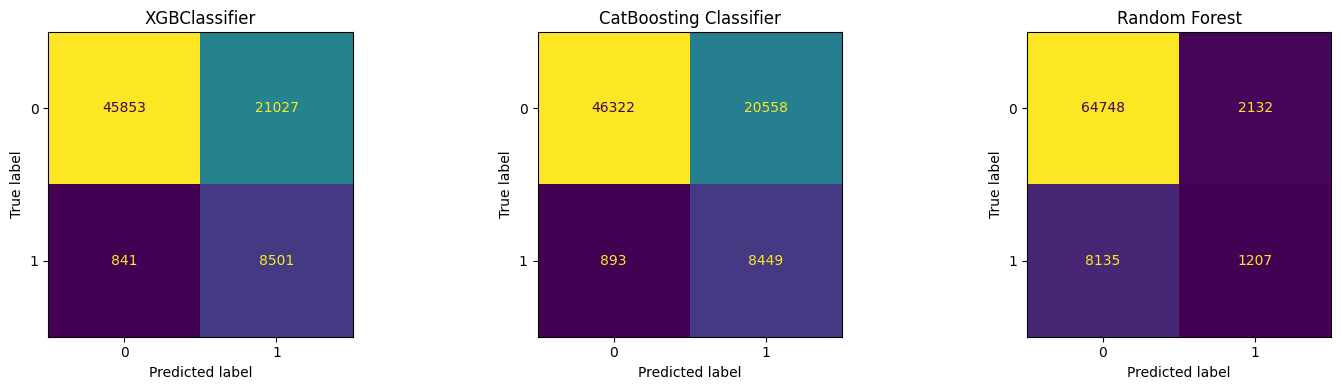

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay

best_models = ['XGBClassifier', 'CatBoosting Classifier', 'Random Forest']

fig, axes = plt.subplots(1,3, figsize=(15,4))
for ax, model_name in zip(axes, best_models):
    ConfusionMatrixDisplay.from_estimator(models[model_name], X_test, y_test, ax = ax, colorbar= False)
    ax.set_title(model_name)

plt.tight_layout()
plt.show()


### Hyperparameter Tuning

In [24]:
xgboost_params = {
    'n_estimators': [200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1, 0.3],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 3, 5]
}

catboost_params = {
    'iterations': [300, 500, 700],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [3, 5, 7, 9],
    'border_count': [64, 128],
    'bagging_temperature': [0, 1, 3],
    'random_strength': [1, 2, 5]
}

rf_params = {
    'n_estimators': [200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}


In [25]:
randomcv_models = [
    ('XGBoost', XGBClassifier(scale_pos_weight = scale_pos_weight, random_state=42), xgboost_params),
    ('CatBoost', CatBoostClassifier(auto_class_weights='Balanced', verbose=False, random_state=42), catboost_params),
    ('RF', RandomForestClassifier(class_weight='balanced', random_state=42), rf_params)
]

In [26]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold


model_param = {}

skfold = StratifiedKFold(
    n_splits = 3,
    shuffle= True,
    random_state= 42
)


for name, model, params in randomcv_models:
    random = RandomizedSearchCV(estimator= model,
                                    param_distributions= params,
                                    n_iter = 20,
                                    cv = skfold,
                                    scoring = 'roc_auc',
                                    verbose= 2,
                                    n_jobs= -1)

    random.fit(X_train, y_train)
    model_param[name] = random.best_params_

for model_name in model_param:
    print(f"----------Best params for {model_name} ----------")
    print(model_param[model_name])

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Fitting 3 folds for each of 20 candidates, totalling 60 fits
----------Best params for XGBoost ----------
{'subsample': 0.8, 'reg_lambda': 3, 'reg_alpha': 0.1, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 7, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.8}
----------Best params for CatBoost ----------
{'random_strength': 2, 'learning_rate': 0.05, 'l2_leaf_reg': 7, 'iterations': 700, 'depth': 6, 'border_count': 64, 'bagging_temperature': 0}
----------Best params for RF ----------
{'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 30, 'bootstrap': True}


In [27]:
model_param

{'XGBoost': {'subsample': 0.8,
  'reg_lambda': 3,
  'reg_alpha': 0.1,
  'n_estimators': 300,
  'min_child_weight': 5,
  'max_depth': 7,
  'learning_rate': 0.05,
  'gamma': 0.1,
  'colsample_bytree': 0.8},
 'CatBoost': {'random_strength': 2,
  'learning_rate': 0.05,
  'l2_leaf_reg': 7,
  'iterations': 700,
  'depth': 6,
  'border_count': 64,
  'bagging_temperature': 0},
 'RF': {'n_estimators': 500,
  'min_samples_split': 10,
  'min_samples_leaf': 2,
  'max_features': 'sqrt',
  'max_depth': 30,
  'bootstrap': True}}

## Retraining the Model with best Parameters

In [28]:
best_models = {
    'XGBoost': XGBClassifier(scale_pos_weight = scale_pos_weight, random_state=42, **model_param['XGBoost']),
    'CatBoost': CatBoostClassifier(auto_class_weights='Balanced', verbose=False, random_state=42, **model_param['CatBoost']),
    'RF': RandomForestClassifier(class_weight='balanced', random_state=42, **model_param['RF'])
}

tuned_report = evaluate_models(
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    models=best_models
)

XGBoost
Model performance for Training set
- Accuracy: 0.7150
- F1 score: 0.4469
- Precision: 0.2932
- Recall: 0.9394
- Roc Auc Score: 0.8710
----------------------------------
Model performance for Test set
- Accuracy: 0.7113
- F1 score: 0.4382
- Precision: 0.2877
- Recall: 0.9185
- Roc Auc Score: 0.8581


CatBoost
Model performance for Training set
- Accuracy: 0.7111
- F1 score: 0.4418
- Precision: 0.2894
- Recall: 0.9326
- Roc Auc Score: 0.8654
----------------------------------
Model performance for Test set
- Accuracy: 0.7095
- F1 score: 0.4376
- Precision: 0.2869
- Recall: 0.9220
- Roc Auc Score: 0.8582


RF
Model performance for Training set
- Accuracy: 0.7329
- F1 score: 0.4655
- Precision: 0.3084
- Recall: 0.9490
- Roc Auc Score: 0.9148
----------------------------------
Model performance for Test set
- Accuracy: 0.7217
- F1 score: 0.4430
- Precision: 0.2935
- Recall: 0.9030
- Roc Auc Score: 0.8542




In [29]:
tuned_report

,Model Name,Accuracy
2,RF,0.721681
0,XGBoost,0.711330
1,CatBoost,0.709546


## Final Model

Among the tuned models, XGBoost achieved the best balance between ROC-AUC, Recall, and overall generalization performance.

Therefore, XGBoost was selected as the final model for deployment.

In [30]:
best_model = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42,**model_param['XGBoost'])

best_model = best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

score = accuracy_score(y_test,y_pred)
y_prob = best_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)
cr = classification_report(y_test, y_pred)

print("FINAL MODEL: XGBoost")
print(f"Accuracy Score: {score:.3f}")
print(f"ROC-AUC Score: {roc_auc:.3f}")
print(f"\nClassification Report: \n{cr}")

FINAL MODEL: XGBoost
Accuracy Score: 0.711
ROC-AUC Score: 0.858

Classification Report: 
              precision    recall  f1-score   support

           0       0.98      0.68      0.81     66880
           1       0.29      0.92      0.44      9342

    accuracy                           0.71     76222
   macro avg       0.64      0.80      0.62     76222
weighted avg       0.90      0.71      0.76     76222



## Confusion Matrix

The confusion matrix provides a detailed breakdown of correct and incorrect predictions made by the final model.

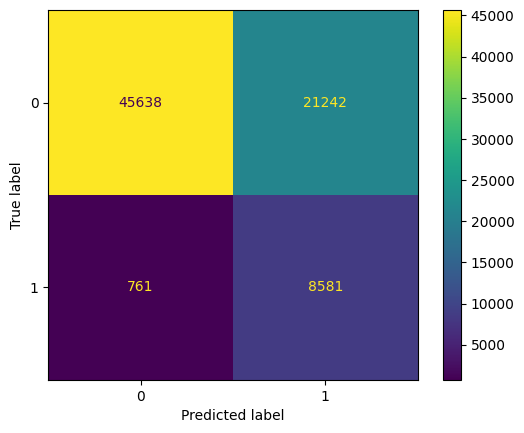

In [31]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)

## ROC Curve

The ROC Curve illustrates the model's ability to distinguish between the positive and negative classes across different classification thresholds.

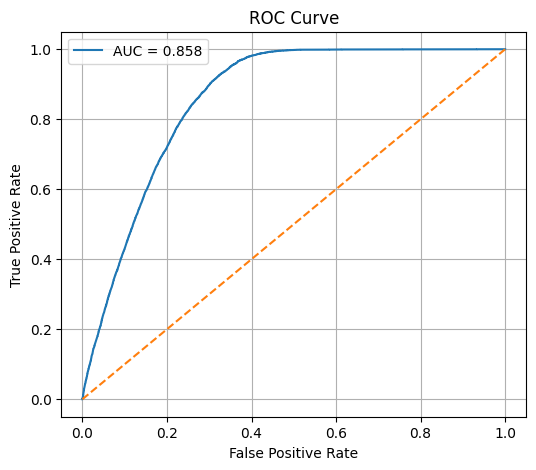

In [32]:
from sklearn.metrics import roc_curve

y_prob = best_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

# Conclusion

In this project, multiple machine learning models were developed and compared for predicting customer interest in vehicle insurance.

Key highlights:

- Built a complete preprocessing pipeline using ColumnTransformer.
- Addressed class imbalance using class-weight based learning.
- Compared multiple machine learning algorithms.
- Performed hyperparameter tuning using RandomizedSearchCV.
- Selected XGBoost as the final model based on ROC-AUC and overall generalization performance.

The trained model is now ready for the MLOps pipeline and deployment.